In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from scipy import stats

In [3]:
data = sns.load_dataset('iris')
data.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
data['species'].unique()  ## tambien se puede usar notacion punto data.species

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [5]:
data['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
x = data['petal_length']
y = data['petal_width']

In [7]:
# agregar columna constante = 1 para calcular interpecto
x = sm.add_constant(x)
x

,const,petal_length
0,1.0,1.4
1,1.0,1.4
2,1.0,1.3
3,1.0,1.5
4,1.0,1.4
...,...,...
145,1.0,5.2
146,1.0,5.0
147,1.0,5.2
148,1.0,5.4


In [8]:
resultado = sm.OLS(y, x).fit()

In [9]:
print(resultado.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.927   
Dependent Variable: petal_width      AIC:                -45.5911
Date:               2026-01-28 08:46 BIC:                -39.5698
No. Observations:   150              Log-Likelihood:     24.796  
Df Model:           1                F-statistic:        1882.   
Df Residuals:       148              Prob (F-statistic): 4.68e-86
R-squared:          0.927            Scale:              0.042636
------------------------------------------------------------------
               Coef.   Std.Err.     t     P>|t|    [0.025   0.975]
------------------------------------------------------------------
const         -0.3631    0.0398  -9.1312  0.0000  -0.4417  -0.2845
petal_length   0.4158    0.0096  43.3872  0.0000   0.3968   0.4347
-----------------------------------------------------------------
Omnibus:              5.765        Durbin-Watson:           1.455
Prob(Omnibus):        

In [10]:
resultado.params

const          -0.363076
petal_length    0.415755
dtype: float64

In [11]:
resultado.rsquared

np.float64(0.9271098389904927)

In [12]:
np.sqrt(resultado.rsquared)

np.float64(0.9628654314027961)

[]

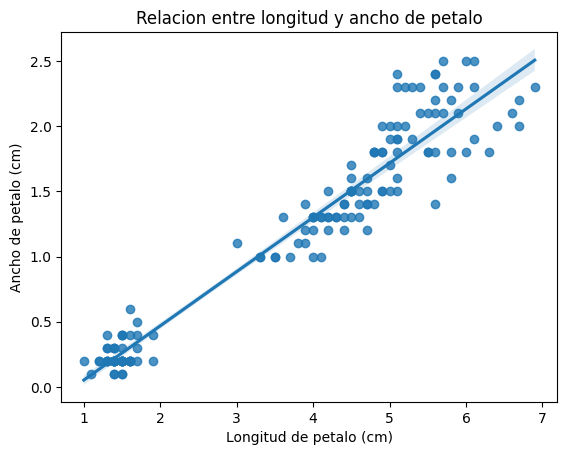

In [13]:
ax = sns.regplot(data = data, x = 'petal_length', y = 'petal_width')
ax.set_xlabel('Longitud de petalo (cm)')
ax.set_ylabel('Ancho de petalo (cm)')
ax.set_title('Relacion entre longitud y ancho de petalo')
ax.plot()

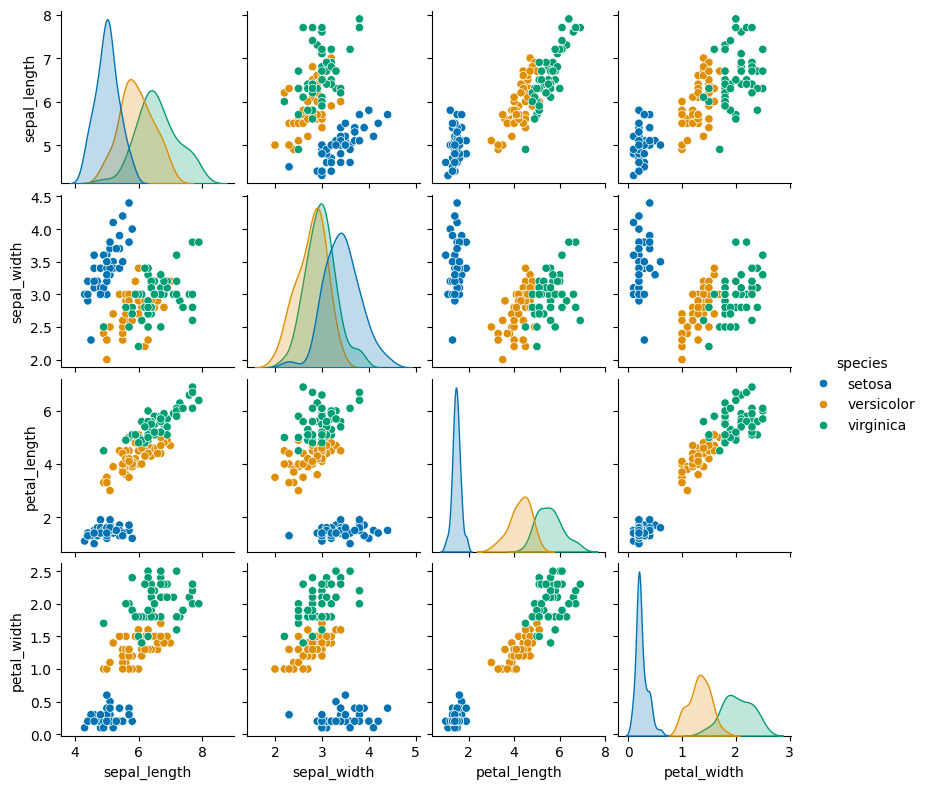

In [14]:
sns.pairplot(data, hue = 'species', height = 2, palette='colorblind');